# Reproducing Online scalable GP+CP
Paper: [arXiv:2410.05444](https://arxiv.org/pdf/2410.05444)

In [1]:
# !pip install numpy scipy scikit-learn matplotlib yfinance

import importlib.util, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import sys
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

In [2]:
ALPHA = 0.1
D_FEAT = 200
RNG_SEED = 42

In [3]:
module_path = "Ensemble Guassian Process.py"

spec = importlib.util.spec_from_file_location("gp", module_path)
gp = importlib.util.module_from_spec(spec)
sys.modules["gp"] = gp
spec.loader.exec_module(gp)

sample_rbf = gp.sample_rbf
sample_matern = gp.sample_matern
sample_laplacian = gp.sample_laplacian
sample_rq = gp.sample_rq

run_online_gp = gp.run_online_gp_recursive
gaussian_loglik = gp.gaussian_loglik
ensemble = gp.ensemble
bayes_credible = gp.bayes_credible
standard_cp = gp.standard_cp
online_conformal = gp.online_conformal
fit_hyperparameters = gp.fit_hyperparameters

In [4]:
# ----- metrics & driver ----------------------------------------------
def long_run_coverage(covered):
    covered = np.asarray(covered, float)
    return np.cumsum(covered) / np.arange(1, len(covered) + 1)


def run_experiment(X, y, alpha=ALPHA, D=D_FEAT, n_init=100,
                   standardize=False, seed=RNG_SEED, varying_kwargs=None):
    """Fit hyper-params, run the online RFF-GP once, evaluate all four methods."""
    rng = np.random.RandomState(seed)
    X = np.asarray(X, float); y = np.asarray(y, float)
    if standardize:                       # causal z-scoring using the warm-up window
        mx, sx = X[:n_init].mean(0), X[:n_init].std(0) + 1e-12
        my, sy = y[:n_init].mean(),  y[:n_init].std()  + 1e-12
        X = (X - mx) / sx; y = (y - my) / sy
    d = X.shape[1]
    length_scale, sigma_f, sigma_n = fit_hyperparameters(X, y, n0=n_init)
    V = sample_rbf(d, D, length_scale, rng)               # paper uses the RBF kernel
    preds, truth, varis = run_online_gp(X, y, V, sigma_n, sigma_f,
                                        n_init=n_init)
    vk = varying_kwargs or {}
    methods = {
        "Bayes credible set":        bayes_credible(truth, preds, varis, alpha),
        "Standard CP":               standard_cp(truth, preds, varis, alpha),
        "OS-GP-CP (fixed eta=0.05)": online_conformal(truth, preds, varis,
                                                       alpha=alpha, step=0.05),   # fixed eta = 0.05
        "OS-GP-CP (varying eta_t)":  online_conformal(truth, preds, varis,
                                                       alpha=alpha, step="varying") ,
    }
    for m in methods.values():                            # ensure a 'size' field
        if "size" not in m:
            m["size"] = np.nan_to_num(m["hi"] - m["lo"], nan=0.0)
    return dict(preds=preds, truth=truth, varis=varis, methods=methods,
                hyper=(length_scale, sigma_f, sigma_n))


# ----- plotting & reporting ------------------------------------------
COLORS = {"Bayes credible set": "C2", "Standard CP": "C3",
          "OS-GP-CP (fixed eta=0.05)": "C1", "OS-GP-CP (varying eta_t)": "C0"}


def _rolling(arr, w=200):
    arr = np.asarray(arr, float)
    return arr if len(arr) < w else np.convolve(arr, np.ones(w) / w, mode="valid")


def plot_results(res, title, alpha=ALPHA, size_window=200, burn_in=100):
    methods = res["methods"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
    for name, m in methods.items():
        lrc = long_run_coverage(m["covered"])
        t = np.arange(len(lrc))
        ax[0].plot(t[burn_in:], lrc[burn_in:], color=COLORS[name], lw=1.5, label=name)
        ax[1].plot(_rolling(m["size"], size_window), color=COLORS[name], lw=1.5, label=name)
    ax[0].axhline(1 - alpha, color="k", ls=":", lw=1, label=f"target {1 - alpha:.2f}")
    for r in methods["OS-GP-CP (varying eta_t)"]["resets"]:
        for a_ in ax:
            a_.axvline(r, color="C0", ls="--", lw=0.7, alpha=0.5)
    ax[0].set(title="Long-run average coverage", xlabel="prediction slot t",
              ylabel="coverage"); ax[0].set_ylim(0.4, 1.02); ax[0].legend(fontsize=7)
    ax[1].set(title=f"Prediction-set size (rolling mean, w={size_window})",
              xlabel="prediction slot t", ylabel="size"); ax[1].legend(fontsize=7)
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def summarize(res, alpha=ALPHA):
    print(f"  fitted hyper-params:  lengthscale={res['hyper'][0]:.3f}  "
          f"sigma_f={res['hyper'][1]:.3f}  sigma_n={res['hyper'][2]:.3f}")
    print(f"  {'method':28s}{'final coverage':>16s}{'mean size':>12s}")
    for name, m in res["methods"].items():
        cov = long_run_coverage(m["covered"])[-1]
        print(f"  {name:28s}{cov:>16.3f}{np.mean(m['size']):>12.3f}")
    rs = res["methods"]["OS-GP-CP (varying eta_t)"]["resets"]
    print(f"  change-points detected (varying eta_t): {rs}")


## Experiment 1

Synthetic i.i.d.:
  fitted hyper-params:  lengthscale=2.055  sigma_f=1.230  sigma_n=0.101
  method                        final coverage   mean size
  Bayes credible set                     0.907       0.334
  Standard CP                            0.899       0.327
  OS-GP-CP (fixed eta=0.05)              0.900       0.330
  OS-GP-CP (varying eta_t)               0.899       0.327
  change-points detected (varying eta_t): []


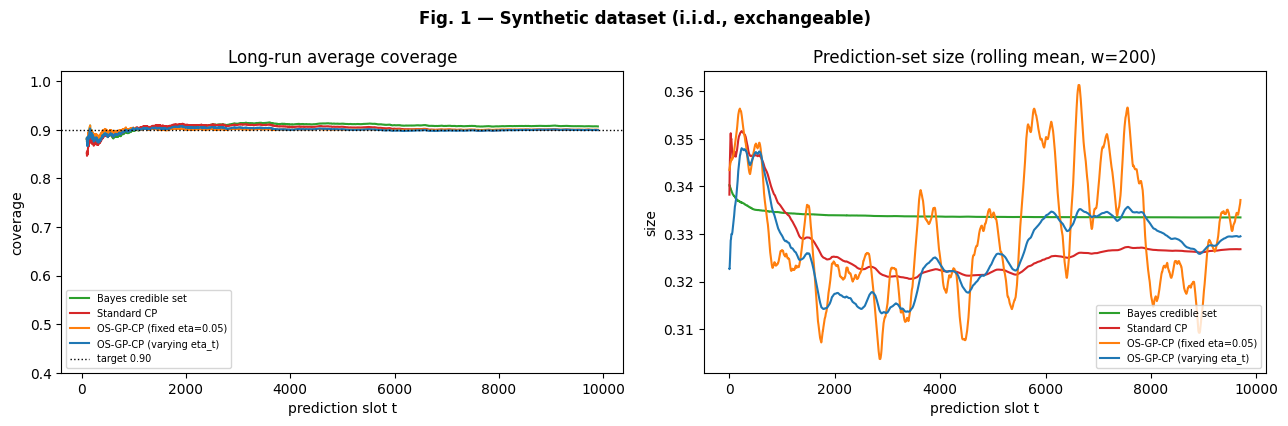

In [5]:
# --- dataset from data.ipynb (cell: "iid data") ---
np.random.seed(42)
X_iid = np.random.rand(10000, 1) * 10
y_iid = np.sin(X_iid[:, 0]) + np.random.randn(10000) * 0.1

res_iid = run_experiment(X_iid, y_iid)
print("Synthetic i.i.d.:")
summarize(res_iid)
plot_results(res_iid, "Fig. 1 — Synthetic dataset (i.i.d., exchangeable)")


## Experiment 2

Synthetic distributional shift:
  fitted hyper-params:  lengthscale=2.055  sigma_f=1.230  sigma_n=0.101
  method                        final coverage   mean size
  Bayes credible set                     0.749       0.334
  Standard CP                            0.816       0.388
  OS-GP-CP (fixed eta=0.05)              0.892       0.486
  OS-GP-CP (varying eta_t)               0.888       0.477
  change-points detected (varying eta_t): [5004]


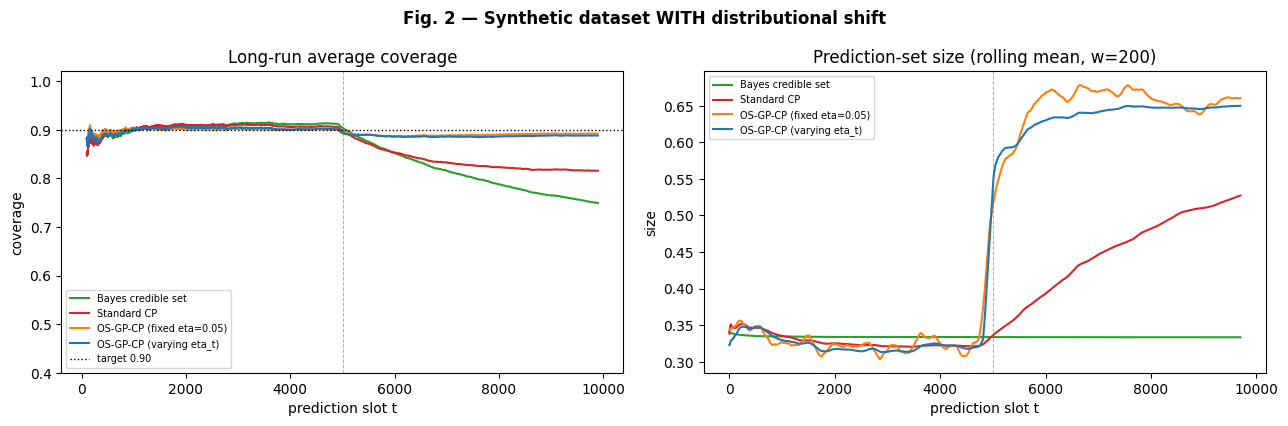

In [6]:
# --- dataset from data.ipynb (cell: "Shift data") ---
np.random.seed(42)
X_shift = np.random.rand(10000, 1) * 10
y_first = np.sin(X_shift[:5000, 0]) + np.random.randn(5000) * 0.1
y_last  = np.sin(X_shift[5000:, 0]) + np.random.randn(5000) * 0.2
y_shift = np.concatenate([y_first, y_last])

res_shift = run_experiment(X_shift, y_shift)
print("Synthetic distributional shift:")
summarize(res_shift)
plot_results(res_shift, "Fig. 2 — Synthetic dataset WITH distributional shift")


## Experiment 3 

Downloaded AAPL: 899 trading days

Real AAPL stock prices:
  fitted hyper-params:  lengthscale=32.842  sigma_f=19.554  sigma_n=0.097
  method                        final coverage   mean size
  Bayes credible set                     0.777       0.331
  Standard CP                            0.795       0.338
  OS-GP-CP (fixed eta=0.05)              0.839       0.376
  OS-GP-CP (varying eta_t)               0.800       0.337
  change-points detected (varying eta_t): []


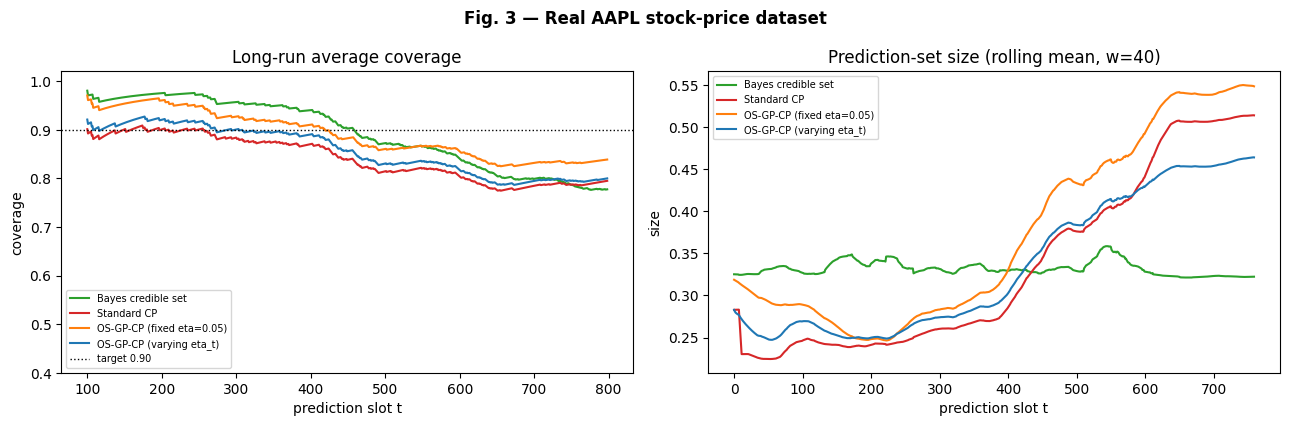

In [7]:
import warnings; warnings.filterwarnings("ignore")

def load_aapl(start="2016-01-04", end="2019-07-31"):
    import yfinance as yf
    data = yf.download("AAPL", start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(data.columns, __import__("pandas").MultiIndex):
        data.columns = data.columns.get_level_values(0)
    X = data[["Open", "High", "Low"]].to_numpy(float)
    y = data["Close"].to_numpy(float).ravel()
    return X, y

try:
    X_aapl, y_aapl = load_aapl()
    print(f"Downloaded AAPL: {len(y_aapl)} trading days")
except Exception as e:
    print("yfinance download failed (", type(e).__name__, ") -> using a drift surrogate.")
    rng = np.random.RandomState(0); T = 900
    level = np.cumsum(rng.randn(T) * 0.6) + 30
    X_aapl = np.c_[level + rng.randn(T) * 0.15, # window size, W = 15
                   level + np.abs(rng.randn(T)) * 0.25,
                   level - np.abs(rng.randn(T)) * 0.25]
    y_aapl = level + rng.randn(T) * 0.2

# fewer points than the synthetic sets -> smaller detector window / cooldown
res_aapl = run_experiment(X_aapl, y_aapl, n_init=100, standardize=True,
                          varying_kwargs=dict(W=50, cooldown=100))
print("\nReal AAPL stock prices:")
summarize(res_aapl)
plot_results(res_aapl, "Fig. 3 — Real AAPL stock-price dataset", size_window=40)


In [8]:
alpha = 0.1
c = norm.ppf(1 - alpha / 2)
c

np.float64(1.6448536269514722)

In [9]:
truth = res_aapl["truth"]; preds = res_aapl["preds"]; sd = np.sqrt(res_aapl["varis"])
for mult in [1, 2, 4, 8]:
    cov = (np.abs(truth - preds) <= c * sd * mult).mean()
    print(f"band width x{mult}: Bayes long-run coverage = {cov:.3f}")

band width x1: Bayes long-run coverage = 0.777
band width x2: Bayes long-run coverage = 0.942
band width x4: Bayes long-run coverage = 0.995
band width x8: Bayes long-run coverage = 1.000


Shift data, OS-GP-CP (varying eta_t):
  single RBF kernel : final coverage = 0.888
  4-kernel ensemble : final coverage = 0.888


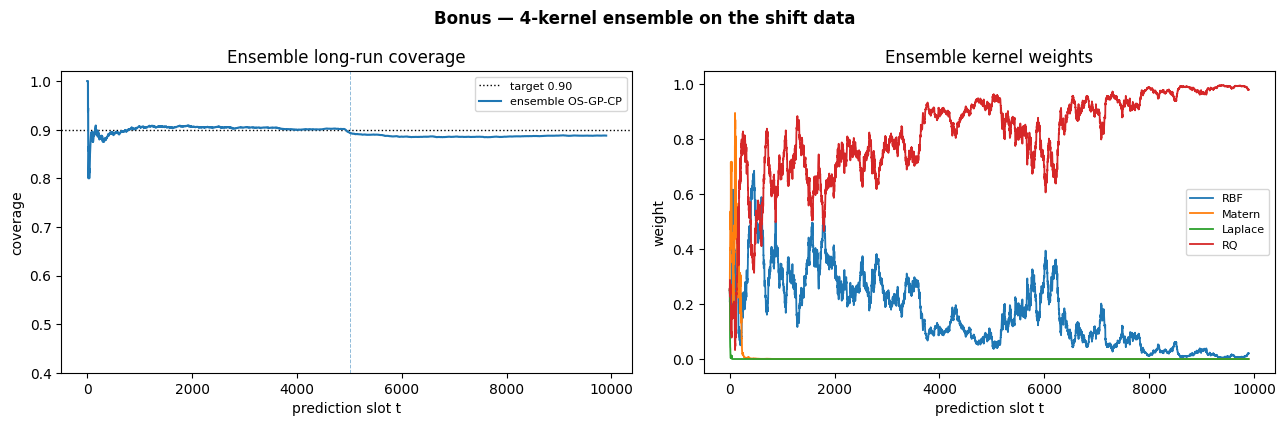

In [11]:
def run_ensemble_experiment(X, y, alpha=ALPHA, D=D_FEAT, n_init=100,
                            standardize=False, seed=RNG_SEED, varying_kwargs=None):
    rng = np.random.RandomState(seed)
    X = np.asarray(X, float); y = np.asarray(y, float)
    if standardize:
        mx, sx = X[:n_init].mean(0), X[:n_init].std(0) + 1e-12
        my, sy = y[:n_init].mean(),  y[:n_init].std()  + 1e-12
        X = (X - mx) / sx; y = (y - my) / sy
    d = X.shape[1]
    ls, sf, sn = fit_hyperparameters(X, y, n0=n_init)
    kernels = {
        "RBF":     sample_rbf(d, D, ls, rng),
        "Matern":  sample_matern(d, D, ls, nu=1.5, rng=rng),
        "Laplace": sample_laplacian(d, D, ls, rng),
        "RQ":      sample_rq(d, D, ls, alpha=2.0, rng=rng),
    }
    preds, varis, truth = {}, {}, None
    for name, V in kernels.items():
        p, t, v = run_online_gp(X, y, V, sn, sf, n_init=n_init)
        preds[name], varis[name], truth = p, v, t
    names = list(kernels)
    P = np.vstack([preds[n] for n in names])
    Vv = np.vstack([varis[n] for n in names])
    LL = np.vstack([gaussian_loglik(truth, preds[n], varis[n]) for n in names])
    ens_mu, ens_var, weight_hist = ensemble(P, Vv, LL)
    vk = varying_kwargs or {}
    cp = online_conformal(truth, ens_mu, ens_var, alpha=alpha, step="varying", **vk)
    return dict(truth=truth, ens_mu=ens_mu, ens_var=ens_var,
                weight_hist=weight_hist, names=names, cp=cp)


ens = run_ensemble_experiment(X_shift, y_shift)
ens_cov = long_run_coverage(ens["cp"]["covered"])[-1]
rbf_cov = long_run_coverage(res_shift["methods"]["OS-GP-CP (varying eta_t)"]["covered"])[-1]
print(f"Shift data, OS-GP-CP (varying eta_t):")
print(f"  single RBF kernel : final coverage = {rbf_cov:.3f}")
print(f"  4-kernel ensemble : final coverage = {ens_cov:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].axhline(1 - ALPHA, color="k", ls=":", lw=1, label="target 0.90")
ax[0].plot(long_run_coverage(ens["cp"]["covered"]), color="C0", lw=1.5, label="ensemble OS-GP-CP")
for r in ens["cp"]["resets"]:
    ax[0].axvline(r, color="C0", ls="--", lw=0.7, alpha=0.5)
ax[0].set(title="Ensemble long-run coverage", xlabel="prediction slot t",
          ylabel="coverage", ylim=(0.4, 1.02)); ax[0].legend(fontsize=8)
for i, n in enumerate(ens["names"]):
    ax[1].plot(ens["weight_hist"][:, i], lw=1.3, label=n)
ax[1].set(title="Ensemble kernel weights", xlabel="prediction slot t", ylabel="weight")
ax[1].legend(fontsize=8); fig.suptitle("Bonus — 4-kernel ensemble on the shift data",
                                       fontweight="bold")
plt.tight_layout(); plt.show()
